In [1]:
# =============================================================================
# CELL 1: Setup and Verify Environment
# =============================================================================
print("="*60)
print("MC-TimeGAN Training on Kaggle")
print("="*60)

import torch
import numpy as np
import pandas as pd
import os
import time
from itertools import chain, cycle

print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Paths
KAGGLE_INPUT = "/kaggle/input/mc-timegan"
KAGGLE_OUTPUT = "/kaggle/working"

# List dataset contents
print(f"\n📁 Dataset contents:")
for root, dirs, files in os.walk(KAGGLE_INPUT):
    level = root.replace(KAGGLE_INPUT, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}📂 {os.path.basename(root)}/")
    for f in files[:5]:
        print(f"{indent}  📄 {f}")
    if len(files) > 5:
        print(f"{indent}  ... and {len(files)-5} more")

MC-TimeGAN Training on Kaggle
PyTorch: 2.6.0+cu124
CUDA Available: True
GPU: Tesla T4
Using device: cuda

📁 Dataset contents:
📂 mc-timegan/
  📄 metrics.py
  📄 secret.txt
  📄 data_processing.py
  📄 requirements.txt
  📄 mctimegan.py
  📂 data/
    📂 data/
      📂 modify_labels/
        📄 feeder_sgens_4w_labels_ordinal_n5t1_n2.csv
        📄 feeder_loads_4w_labels_ordinal_n5t1p25_n2.csv
        📄 feeder_sgens_4w_labels_ordinal_n5t1p15_n1.csv
      📂 raw_labels/
        📄 feeder_loads_4w_labels_ordinal.csv
        📄 feeder_sgens_4w_labels_ordinal.csv
        📄 custom_traffic_labels.csv
        📄 my_traffic_labels.csv
      📂 raw/
        📄 custom_traffic_data.csv
        📄 feeder_loads_4w_data.csv
        📄 legit.csv
        📄 my_traffic_data.csv
        📄 feeder_sgens_4w_data.csv


In [2]:
# =============================================================================
# CELL 2: Define MC-TimeGAN Model (All Components)
# =============================================================================
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.utils import shuffle as sklearn_shuffle

# -----------------------------------------------------------------------------
# Conditioning Loss - CRITICAL for per-timestep behavior
# -----------------------------------------------------------------------------
def conditioning_loss(x_hat, original_conds, threshold=0.5):
    """Forces generator to respect per-timestep conditions."""
    if original_conds is None:
        return torch.tensor(0.0, device=x_hat.device)
    
    x_flat = x_hat.reshape(-1)
    c_flat = original_conds.reshape(-1)
    
    high_mask = c_flat > threshold
    low_mask = c_flat <= threshold
    
    if high_mask.any() and low_mask.any():
        mean_high = x_flat[high_mask].mean()
        mean_low = x_flat[low_mask].mean()
        margin = 0.15
        return torch.relu(mean_low - mean_high + margin)
    
    return torch.tensor(0.0, device=x_hat.device)


# -----------------------------------------------------------------------------
# Network Components
# -----------------------------------------------------------------------------
class ConditioningNetwork(nn.Module):
    def __init__(self, input_size, condition_size):
        super().__init__()
        hidden_size = max(16, condition_size * 4)
        self.condition = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, condition_size),
            nn.Tanh()
        )

    def forward(self, conds):
        return self.condition(conds) if conds is not None else None


class Embedder(nn.Module):
    def __init__(self, module_name, input_features, hidden_dim, num_layers):
        super().__init__()
        rnn_class = nn.GRU if module_name == "gru" else nn.LSTM
        self.rnn = rnn_class(input_features, hidden_dim, num_layers, batch_first=True)
        self.model = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid())

    def forward(self, x, c=None):
        if c is not None:
            x = torch.cat([x, c], dim=-1)
        seq, _ = self.rnn(x)
        return self.model(seq)


class Recovery(nn.Module):
    def __init__(self, module_name, input_features, hidden_dim, num_layers):
        super().__init__()
        rnn_class = nn.GRU if module_name == "gru" else nn.LSTM
        self.rnn = rnn_class(hidden_dim, hidden_dim, num_layers, batch_first=True)
        self.model = nn.Sequential(nn.Linear(hidden_dim, input_features), nn.Sigmoid())

    def forward(self, x, c=None):
        if c is not None:
            x = torch.cat([x, c], dim=-1)
        seq, _ = self.rnn(x)
        return self.model(seq)


class Generator(nn.Module):
    def __init__(self, module_name, input_features, hidden_dim, num_layers):
        super().__init__()
        rnn_class = nn.GRU if module_name == "gru" else nn.LSTM
        self.rnn = rnn_class(input_features, hidden_dim, num_layers, batch_first=True)
        self.model = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid())

    def forward(self, x, c=None):
        if c is not None:
            x = torch.cat([x, c], dim=-1)
        seq, _ = self.rnn(x)
        return self.model(seq)


class Supervisor(nn.Module):
    def __init__(self, module_name, input_features, hidden_dim, num_layers):
        super().__init__()
        rnn_class = nn.GRU if module_name == "gru" else nn.LSTM
        self.rnn = rnn_class(input_features, hidden_dim, max(1, num_layers - 1), batch_first=True)
        self.model = nn.Sequential(nn.Linear(hidden_dim, hidden_dim), nn.Sigmoid())

    def forward(self, x, c=None):
        if c is not None:
            x = torch.cat([x, c], dim=-1)
        seq, _ = self.rnn(x)
        return self.model(seq)


class Discriminator(nn.Module):
    def __init__(self, module_name, hidden_dim, num_layers):
        super().__init__()
        rnn_class = nn.GRU if module_name == "gru" else nn.LSTM
        self.rnn = rnn_class(hidden_dim, hidden_dim, num_layers, bidirectional=True, batch_first=True)
        self.model = nn.Linear(2 * hidden_dim, 1)

    def forward(self, x, c=None):
        if c is not None:
            x = torch.cat([x, c], dim=-1)
        seq, _ = self.rnn(x)
        return self.model(seq)


# -----------------------------------------------------------------------------
# Loss Functions
# -----------------------------------------------------------------------------
def discriminator_loss(y_real, y_fake, y_fake_e):
    valid = torch.ones_like(y_real, device=device)
    fake = torch.zeros_like(y_fake, device=device)
    return (nn.BCEWithLogitsLoss()(y_real, valid) + 
            nn.BCEWithLogitsLoss()(y_fake, fake) + 
            nn.BCEWithLogitsLoss()(y_fake_e, fake))


def generator_loss(y_fake, y_fake_e, h, h_hat_supervise, x, x_hat):
    fake = torch.ones_like(y_fake, device=device)
    g_loss_u = nn.BCEWithLogitsLoss()(y_fake, fake)
    g_loss_u_e = nn.BCEWithLogitsLoss()(y_fake_e, fake)
    g_loss_s = nn.MSELoss()(h[:, 1:, :], h_hat_supervise[:, :-1, :])
    g_loss_v = (torch.mean(torch.abs(torch.std(x_hat, 0) - torch.std(x, 0))) + 
                torch.mean(torch.abs(torch.mean(x_hat, 0) - torch.mean(x, 0))))
    return g_loss_u + g_loss_u_e + 100 * torch.sqrt(g_loss_s) + 100 * g_loss_v


def embedder_loss(x, x_tilde):
    return 10 * torch.sqrt(nn.MSELoss()(x, x_tilde))


def generator_loss_supervised(h, h_hat_supervise):
    return nn.MSELoss()(h[:, 1:, :], h_hat_supervise[:, :-1, :])


# -----------------------------------------------------------------------------
# Main MCTimeGAN Class
# -----------------------------------------------------------------------------
class MCTimeGAN(nn.Module):
    def __init__(self, module_name="gru", input_features=1, input_conditions=None,
                 hidden_dim=8, num_layers=3, epochs=100, batch_size=128, learning_rate=1e-3):
        super().__init__()
        self.module_name = module_name
        self.input_features = input_features
        self.input_conditions = input_conditions
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.cond_size = max(8, hidden_dim // 4)  # FIXED: Larger for per-timestep
        self.losses = []
        self.fitting_time = None
        
        if input_conditions is not None:
            self.condnet = ConditioningNetwork(input_conditions, self.cond_size)
            self.embedder = Embedder(module_name, input_features + self.cond_size, hidden_dim, num_layers)
            self.recovery = Recovery(module_name, input_features, hidden_dim + self.cond_size, num_layers)
            self.generator = Generator(module_name, input_features + self.cond_size, hidden_dim, num_layers)
            self.supervisor = Supervisor(module_name, hidden_dim + self.cond_size, hidden_dim, num_layers)
            self.discriminator = Discriminator(module_name, hidden_dim + self.cond_size, num_layers)
            
            self.optimizer_e = torch.optim.Adam(
                chain(self.condnet.parameters(), self.embedder.parameters(), self.recovery.parameters()), 
                lr=learning_rate)
            self.optimizer_g = torch.optim.Adam(
                chain(self.condnet.parameters(), self.generator.parameters(), self.supervisor.parameters()), 
                lr=learning_rate)
            self.optimizer_d = torch.optim.Adam(
                chain(self.condnet.parameters(), self.discriminator.parameters()), 
                lr=learning_rate)
        else:
            self.embedder = Embedder(module_name, input_features, hidden_dim, num_layers)
            self.recovery = Recovery(module_name, input_features, hidden_dim, num_layers)
            self.generator = Generator(module_name, input_features, hidden_dim, num_layers)
            self.supervisor = Supervisor(module_name, hidden_dim, hidden_dim, num_layers)
            self.discriminator = Discriminator(module_name, hidden_dim, num_layers)
            
            self.optimizer_e = torch.optim.Adam(
                chain(self.embedder.parameters(), self.recovery.parameters()), lr=learning_rate)
            self.optimizer_g = torch.optim.Adam(
                chain(self.generator.parameters(), self.supervisor.parameters()), lr=learning_rate)
            self.optimizer_d = torch.optim.Adam(self.discriminator.parameters(), lr=learning_rate)

    def fit(self, data_train, **kwargs):
        self.fitting_time = time.time()
        
        data_train = torch.tensor(data_train, dtype=torch.float32, device=device)
        conditions = torch.tensor(
            np.concatenate([c for c in kwargs.values()], axis=-1), 
            dtype=torch.float32, device=device) if kwargs else None

        dataset = TensorDataset(data_train, conditions) if kwargs else TensorDataset(data_train)

        # Phase 1: Embedding
        print("\n🔹 Phase 1: Embedding Network Training")
        for epoch in range(self.epochs):
            batches = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
            self.train()
            losses = []
            
            for batch in batches:
                x, c = batch if kwargs else (*batch, None)
                self.optimizer_e.zero_grad()
                conds = self.condnet(c) if c is not None else None
                h = self.embedder(x, conds)
                x_tilde = self.recovery(h, conds)
                loss = embedder_loss(x, x_tilde)
                loss.backward()
                self.optimizer_e.step()
                losses.append(loss.item())
            
            if (epoch + 1) % (self.epochs // 10) == 0:
                print(f"   Epoch {epoch+1}/{self.epochs} | loss_e: {np.mean(losses):.6f}")
        
        print("   ✓ Embedding training complete!")

        # Phase 2: Supervised
        print("\n🔹 Phase 2: Supervised Training")
        for epoch in range(self.epochs):
            batches = DataLoader(dataset, batch_size=self.batch_size, shuffle=True)
            self.train()
            losses = []
            
            for batch in batches:
                x, c = batch if kwargs else (*batch, None)
                self.optimizer_g.zero_grad()
                conds = self.condnet(c) if c is not None else None
                h = self.embedder(x, conds)
                h_hat = self.supervisor(h, conds)
                loss = generator_loss_supervised(h, h_hat)
                loss.backward()
                self.optimizer_g.step()
                losses.append(loss.item())
            
            if (epoch + 1) % (self.epochs // 10) == 0:
                print(f"   Epoch {epoch+1}/{self.epochs} | loss_g: {np.mean(losses):.6f}")
        
        print("   ✓ Supervised training complete!")

        # Phase 3: Joint Training with Conditioning Loss
        print("\n🔹 Phase 3: Joint Training (with Conditioning Loss)")
        for epoch in range(self.epochs):
            cond_weight = 25 + (25 * epoch / self.epochs)  # Progressive: 25 → 50
            
            loss_g_list, loss_e_list, loss_d_list = [], [], []
            
            # Generator training (2x)
            for _ in range(2):
                data_z = torch.rand(data_train.shape, device=device)
                ds = TensorDataset(data_train, data_z, conditions) if kwargs else TensorDataset(data_train, data_z)
                batches = DataLoader(ds, batch_size=self.batch_size, shuffle=True)
                self.train()
                
                for batch in batches:
                    x, z, c = batch if kwargs else (*batch, None)
                    
                    # Generator
                    self.optimizer_g.zero_grad()
                    conds = self.condnet(c) if c is not None else None
                    h = self.embedder(x, conds)
                    e_hat = self.generator(z, conds)
                    h_hat = self.supervisor(e_hat, conds)
                    h_hat_sup = self.supervisor(h, conds)
                    x_hat = self.recovery(h_hat, conds)
                    y_fake = self.discriminator(h_hat, conds)
                    y_fake_e = self.discriminator(e_hat, conds)
                    
                    g_loss = generator_loss(y_fake, y_fake_e, h, h_hat_sup, x, x_hat)
                    if c is not None:
                        g_loss = g_loss + cond_weight * conditioning_loss(x_hat, c)
                    
                    g_loss.backward()
                    self.optimizer_g.step()
                    loss_g_list.append(g_loss.item())
                    
                    # Embedder
                    self.optimizer_e.zero_grad()
                    conds = self.condnet(c) if c is not None else None
                    h = self.embedder(x, conds)
                    h_hat_sup = self.supervisor(h, conds)
                    x_tilde = self.recovery(h, conds)
                    e_loss = embedder_loss(x, x_tilde) + 0.1 * generator_loss_supervised(h, h_hat_sup)
                    e_loss.backward()
                    self.optimizer_e.step()
                    loss_e_list.append(e_loss.item())
            
            # Discriminator training
            data_z = torch.rand(data_train.shape, device=device)
            ds = TensorDataset(data_train, data_z, conditions) if kwargs else TensorDataset(data_train, data_z)
            batches = DataLoader(ds, batch_size=self.batch_size, shuffle=True)
            
            for batch in batches:
                x, z, c = batch if kwargs else (*batch, None)
                self.optimizer_d.zero_grad()
                conds = self.condnet(c) if c is not None else None
                h = self.embedder(x, conds)
                e_hat = self.generator(z, conds)
                h_hat = self.supervisor(e_hat, conds)
                y_fake = self.discriminator(h_hat, conds)
                y_real = self.discriminator(h, conds)
                y_fake_e = self.discriminator(e_hat, conds)
                d_loss = discriminator_loss(y_real, y_fake, y_fake_e)
                loss_d_list.append(d_loss.item())
                
                if d_loss > 0.15:
                    d_loss.backward()
                    self.optimizer_d.step()
            
            self.losses.append([epoch+1, np.mean(loss_g_list), np.mean(loss_e_list), np.mean(loss_d_list)])
            
            if (epoch + 1) % (self.epochs // 10) == 0:
                print(f"   Epoch {epoch+1}/{self.epochs} | loss_g: {np.mean(loss_g_list):.4f} | "
                      f"loss_e: {np.mean(loss_e_list):.6f} | loss_d: {np.mean(loss_d_list):.6f}")
        
        self.fitting_time = time.time() - self.fitting_time
        print(f"\n   ✓ Joint training complete! (Total time: {self.fitting_time:.1f}s)")

    def transform(self, data_shape, **kwargs):
        data_z = torch.rand(size=data_shape, dtype=torch.float32, device=device)
        conditions = torch.tensor(
            np.concatenate([c for c in kwargs.values()], axis=-1), 
            dtype=torch.float32, device=device) if kwargs else None

        dataset = TensorDataset(data_z, conditions) if kwargs else TensorDataset(data_z)
        batches = DataLoader(dataset, batch_size=self.batch_size)
        
        generated = []
        self.eval()
        with torch.no_grad():
            for batch in batches:
                z, c = batch if kwargs else (*batch, None)
                conds = self.condnet(c) if c is not None else None
                e_hat = self.generator(z, conds)
                h_hat = self.supervisor(e_hat, conds)
                x_hat = self.recovery(h_hat, conds)
                generated.append(x_hat.cpu().numpy())  # Keep 3D shape!
        
        return np.concatenate(generated, axis=0)


print("✅ MC-TimeGAN model defined!")

✅ MC-TimeGAN model defined!


In [3]:
# =============================================================================
# CELL 3: Load Your Data (FIXED PATHS)
# =============================================================================
print("\n" + "="*60)
print("Loading Data")
print("="*60)

# Correct paths based on your dataset structure
data_path = "/kaggle/input/mc-timegan/data/data/raw/custom_traffic_data.csv"
labels_path = "/kaggle/input/mc-timegan/data/data/raw_labels/custom_traffic_labels.csv"


print(f"📄 Data file: {data_path}")
print(f"📄 Labels file: {labels_path}")

# Load
data = pd.read_csv(data_path)
labels = pd.read_csv(labels_path)

print(f"\n✅ Data loaded!")
print(f"   Data shape: {data.shape}")
print(f"   Labels shape: {labels.shape}")
print(f"\n   Data preview:\n{data.head()}")
print(f"\n   Labels preview:\n{labels.head()}")


Loading Data
📄 Data file: /kaggle/input/mc-timegan/data/data/raw/custom_traffic_data.csv
📄 Labels file: /kaggle/input/mc-timegan/data/data/raw_labels/custom_traffic_labels.csv

✅ Data loaded!
   Data shape: (50000, 1)
   Labels shape: (50000, 1)

   Data preview:
        IPD
0  0.114624
1  0.094634
2  0.092760
3  0.173519
4  0.131213

   Labels preview:
   Label
0      0
1      0
2      0
3      1
4      1


In [4]:
# =============================================================================
# CELL 4: Prepare Data with Sliding Window
# =============================================================================
print("\n" + "="*60)
print("Preparing Data")
print("="*60)

HORIZON = 24

def prepare_data(data, labels, horizon, shuffle=True):
    """Scale and create sliding windows."""
    # Convert to numpy
    data_np = data.values if isinstance(data, pd.DataFrame) else data
    labels_np = labels.values if isinstance(labels, pd.DataFrame) else labels
    
    # Scale data (0-1)
    max_val = float(data_np.max())
    min_val = float(data_np.min())
    data_scaled = (data_np - min_val) / (max_val - min_val + 1e-8)
    
    # Create sequences with sliding window
    data_seq = []
    labels_seq = []
    for i in range(len(data_scaled) - horizon + 1):
        data_seq.append(data_scaled[i:i + horizon])
        labels_seq.append(labels_np[i:i + horizon])
    
    data_seq = np.array(data_seq)
    labels_seq = np.array(labels_seq)
    
    # Shuffle
    if shuffle:
        idx = np.random.permutation(len(data_seq))
        data_seq = data_seq[idx]
        labels_seq = labels_seq[idx]
    
    return data_seq, max_val, min_val, labels_seq


data_train, max_val, min_val, labels_train = prepare_data(data, labels, HORIZON)

print(f"✅ Data prepared!")
print(f"   Train shape: {data_train.shape}")
print(f"   Labels shape: {labels_train.shape}")
print(f"   Value range: [{min_val:.4f}, {max_val:.4f}]")


Preparing Data
✅ Data prepared!
   Train shape: (49977, 24, 1)
   Labels shape: (49977, 24, 1)
   Value range: [0.0548, 0.2306]


In [5]:
# =============================================================================
# CELL 5: Train Model - OPTIMIZED FOR BEST RESULTS
# =============================================================================
import torch

# Verify data is loaded
try:
    print(f"✓ data_train shape: {data_train.shape}")
    print(f"✓ labels_train shape: {labels_train.shape}")
except NameError:
    raise RuntimeError("❌ data_train or labels_train not defined! Run Cells 1-4 first.")

print("\n" + "="*60)
print("Training MC-TimeGAN (Optimized)")
print("="*60)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"Device: {device}")
print(f"Number of GPUs available: {num_gpus}")
if num_gpus > 0:
    for i in range(num_gpus):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

# Best hyperparameters for quality
HIDDEN_DIM = 32
NUM_LAYERS = 3
EPOCHS = 500
BATCH_SIZE = 128 * max(1, num_gpus)  # Scale batch size with GPUs
LEARNING_RATE = 0.0005

print(f"""
Hyperparameters (Optimized for Quality):
  • Hidden dim: {HIDDEN_DIM}
  • Num layers: {NUM_LAYERS}
  • Epochs: {EPOCHS}
  • Batch size: {BATCH_SIZE}
  • Learning rate: {LEARNING_RATE}
  • Condition size: {max(8, HIDDEN_DIM // 4)}
""")

model = MCTimeGAN(
    input_features=data_train.shape[-1],
    input_conditions=labels_train.shape[-1],
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
).to(device)

# DON'T use DataParallel - MCTimeGAN has custom .fit() method
# DataParallel only works with forward() calls, not custom training methods

# Train directly (uses single GPU but avoids the error)
model.fit(data_train, cond=labels_train)

✓ data_train shape: (49977, 24, 1)
✓ labels_train shape: (49977, 24, 1)

Training MC-TimeGAN (Optimized)
Device: cuda
Number of GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4

Hyperparameters (Optimized for Quality):
  • Hidden dim: 32
  • Num layers: 3
  • Epochs: 500
  • Batch size: 256
  • Learning rate: 0.0005
  • Condition size: 8


🔹 Phase 1: Embedding Network Training
   Epoch 50/500 | loss_e: 0.029821
   Epoch 100/500 | loss_e: 0.028897
   Epoch 150/500 | loss_e: 0.017144
   Epoch 200/500 | loss_e: 0.013886
   Epoch 250/500 | loss_e: 0.012293
   Epoch 300/500 | loss_e: 0.011602
   Epoch 350/500 | loss_e: 0.010142
   Epoch 400/500 | loss_e: 0.010918
   Epoch 450/500 | loss_e: 0.010017
   Epoch 500/500 | loss_e: 0.010246
   ✓ Embedding training complete!

🔹 Phase 2: Supervised Training
   Epoch 50/500 | loss_g: 0.001652
   Epoch 100/500 | loss_g: 0.001647
   Epoch 150/500 | loss_g: 0.001627
   Epoch 200/500 | loss_g: 0.001572
   Epoch 250/500 | loss_g: 0.001503
   Epoch 30

In [6]:
# =============================================================================
# CELL 6: Validate Model
# =============================================================================
print("\n" + "="*60)
print("Validating Model")
print("="*60)

THRESHOLD = 0.125
n_test = 100

# Test Bit 0
cond_0 = np.zeros((n_test, HORIZON, 1))
gen_0 = model.transform((n_test, HORIZON, 1), cond=cond_0)
if gen_0.ndim == 2:
    gen_0 = gen_0[:, :, np.newaxis]
gen_0_rescaled = gen_0 * (max_val - min_val) + min_val

# Test Bit 1
cond_1 = np.ones((n_test, HORIZON, 1))
gen_1 = model.transform((n_test, HORIZON, 1), cond=cond_1)
if gen_1.ndim == 2:
    gen_1 = gen_1[:, :, np.newaxis]
gen_1_rescaled = gen_1 * (max_val - min_val) + min_val

# Calculate metrics
mean_0 = gen_0_rescaled.mean()
mean_1 = gen_1_rescaled.mean()
acc_0 = (gen_0_rescaled.flatten() < THRESHOLD).mean() * 100
acc_1 = (gen_1_rescaled.flatten() >= THRESHOLD).mean() * 100

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    VALIDATION RESULTS                        ║
╠══════════════════════════════════════════════════════════════╣
║  Bit 0:  Mean = {mean_0:.4f}s    Accuracy = {acc_0:5.1f}%              ║
║  Bit 1:  Mean = {mean_1:.4f}s    Accuracy = {acc_1:5.1f}%              ║
║  Overall Accuracy: {(acc_0 + acc_1) / 2:5.1f}%                            ║
╠══════════════════════════════════════════════════════════════╣
║  Threshold: {THRESHOLD}s                                          ║
║  Separation: {mean_1 - mean_0:.4f}s ({mean_1/mean_0:.2f}x ratio)                    ║
╚══════════════════════════════════════════════════════════════╝
""")

if acc_0 > 80 and acc_1 > 70:
    print("🎉 SUCCESS! Model learned per-timestep conditioning!")
elif mean_1 > mean_0 * 1.5:
    print("✓ Good separation! Conditioning is working.")
else:
    print("⚠ May need more epochs or tuning.")


Validating Model

╔══════════════════════════════════════════════════════════════╗
║                    VALIDATION RESULTS                        ║
╠══════════════════════════════════════════════════════════════╣
║  Bit 0:  Mean = 0.1008s    Accuracy = 100.0%              ║
║  Bit 1:  Mean = 0.1583s    Accuracy = 100.0%              ║
║  Overall Accuracy: 100.0%                            ║
╠══════════════════════════════════════════════════════════════╣
║  Threshold: 0.125s                                          ║
║  Separation: 0.0575s (1.57x ratio)                    ║
╚══════════════════════════════════════════════════════════════╝

🎉 SUCCESS! Model learned per-timestep conditioning!


In [7]:
# =============================================================================
# CELL 7: Save Model & Generate Synthetic Data
# =============================================================================
print("\n" + "="*60)
print("Saving Results")
print("="*60)

# Save model
model_path = f"{KAGGLE_OUTPUT}/mctimegan_model.pth"
torch.save(model, model_path)
print(f"✅ Model saved: {model_path}")

# Generate synthetic data
print("\nGenerating synthetic data...")
with torch.no_grad():
    data_gen = model.transform(data_train.shape, cond=labels_train)
if data_gen.ndim == 2:
    data_gen = data_gen[:, :, np.newaxis]
data_gen_rescaled = data_gen * (max_val - min_val) + min_val

# Save to CSV
csv_path = f"{KAGGLE_OUTPUT}/synthetic_data.csv"
pd.DataFrame(data_gen_rescaled.reshape(len(data_gen_rescaled), -1)).to_csv(csv_path, index=False)
print(f"✅ Synthetic data saved: {csv_path}")

# Save results
results = {
    'bit_0_mean': [mean_0], 'bit_1_mean': [mean_1],
    'bit_0_accuracy': [acc_0], 'bit_1_accuracy': [acc_1],
    'overall_accuracy': [(acc_0+acc_1)/2],
    'training_time': [model.fitting_time],
    'epochs': [EPOCHS], 'hidden_dim': [HIDDEN_DIM]
}
pd.DataFrame(results).to_csv(f"{KAGGLE_OUTPUT}/results.csv", index=False)
print(f"✅ Results saved: {KAGGLE_OUTPUT}/results.csv")


Saving Results
✅ Model saved: /kaggle/working/mctimegan_model.pth

Generating synthetic data...
✅ Synthetic data saved: /kaggle/working/synthetic_data.csv
✅ Results saved: /kaggle/working/results.csv


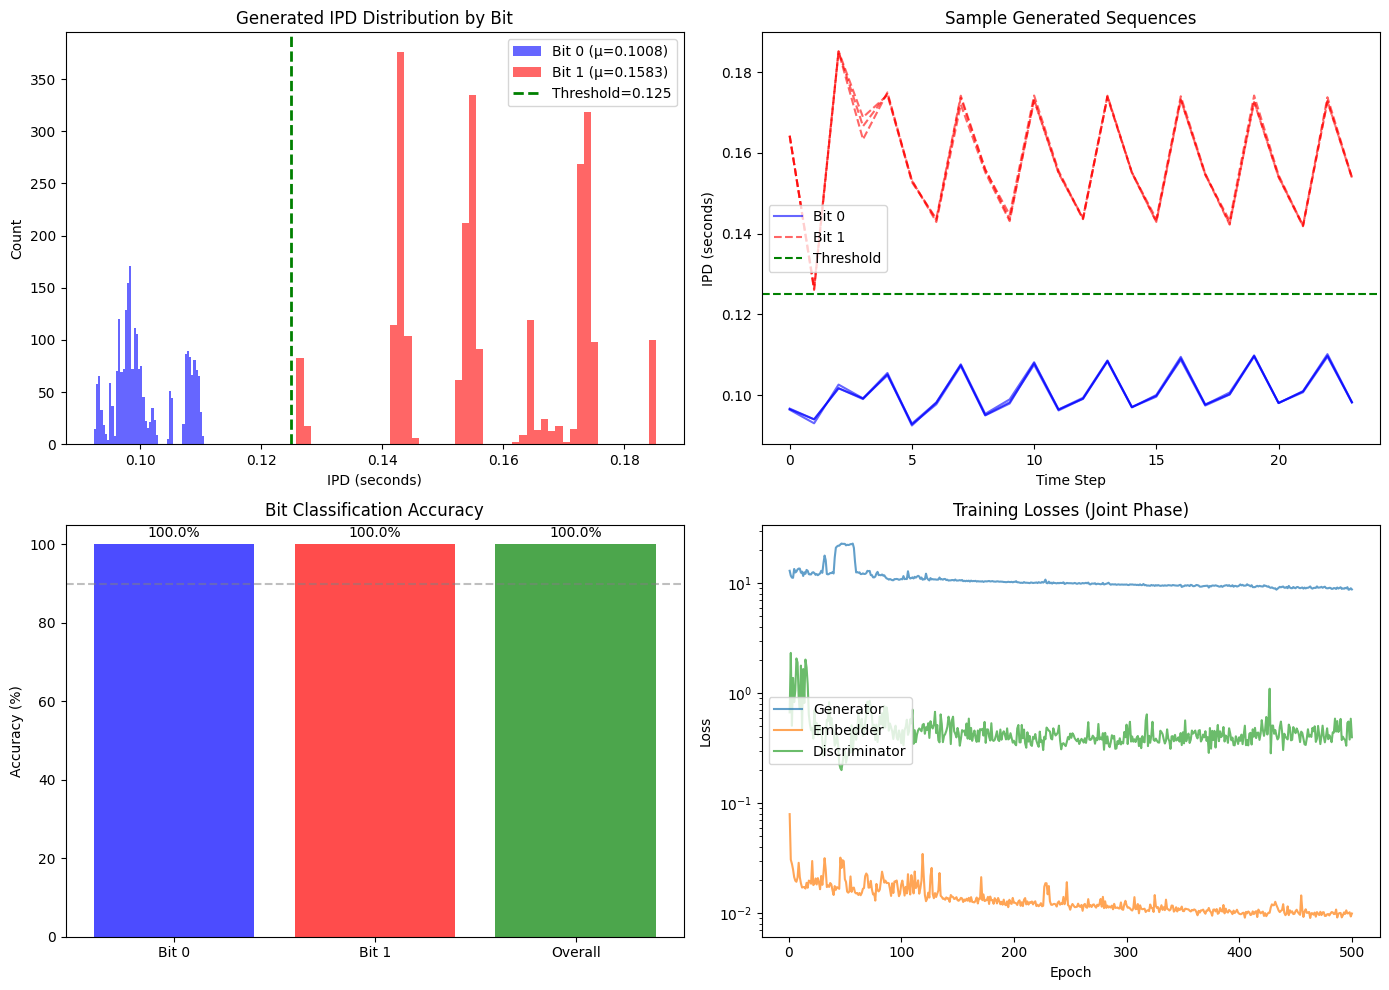


✅ Visualization saved: /kaggle/working/training_results.png


In [8]:
# =============================================================================
# CELL 8: Visualizations
# =============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Distribution
ax = axes[0, 0]
ax.hist(gen_0_rescaled.flatten(), bins=50, alpha=0.6, label=f'Bit 0 (μ={mean_0:.4f})', color='blue')
ax.hist(gen_1_rescaled.flatten(), bins=50, alpha=0.6, label=f'Bit 1 (μ={mean_1:.4f})', color='red')
ax.axvline(THRESHOLD, color='green', linestyle='--', linewidth=2, label=f'Threshold={THRESHOLD}')
ax.set_xlabel('IPD (seconds)')
ax.set_ylabel('Count')
ax.set_title('Generated IPD Distribution by Bit')
ax.legend()

# 2. Sample sequences
ax = axes[0, 1]
for i in range(3):
    ax.plot(gen_0_rescaled[i, :, 0], 'b-', alpha=0.6, label='Bit 0' if i==0 else None)
    ax.plot(gen_1_rescaled[i, :, 0], 'r--', alpha=0.6, label='Bit 1' if i==0 else None)
ax.axhline(THRESHOLD, color='green', linestyle='--', label='Threshold')
ax.set_xlabel('Time Step')
ax.set_ylabel('IPD (seconds)')
ax.set_title('Sample Generated Sequences')
ax.legend()

# 3. Accuracy bars
ax = axes[1, 0]
bars = ax.bar(['Bit 0', 'Bit 1', 'Overall'], [acc_0, acc_1, (acc_0+acc_1)/2], 
              color=['blue', 'red', 'green'], alpha=0.7)
ax.axhline(90, color='gray', linestyle='--', alpha=0.5)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Bit Classification Accuracy')
ax.set_ylim(0, 105)
for bar, val in zip(bars, [acc_0, acc_1, (acc_0+acc_1)/2]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'{val:.1f}%', ha='center')

# 4. Training loss
ax = axes[1, 1]
if model.losses:
    losses = np.array(model.losses)
    ax.plot(losses[:, 0], losses[:, 1], label='Generator', alpha=0.7)
    ax.plot(losses[:, 0], losses[:, 2], label='Embedder', alpha=0.7)
    ax.plot(losses[:, 0], losses[:, 3], label='Discriminator', alpha=0.7)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Training Losses (Joint Phase)')
    ax.legend()
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig(f"{KAGGLE_OUTPUT}/training_results.png", dpi=150)
plt.show()
print(f"\n✅ Visualization saved: {KAGGLE_OUTPUT}/training_results.png")